In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("../data/raw/Crop_Recommendation_Non Cassava.csv")

# =====================================================
# BASIC INFORMATION
# =====================================================

print("="*50)
print("SHAPE")
print("="*50)
print(df.shape)

print("\n")

print("="*50)
print("DATA TYPES")
print("="*50)
print(df.dtypes)

print("\n")

print("="*50)
print("MISSING VALUES")
print("="*50)
print(df.isnull().sum())

print("\n")

print("="*50)
print("DUPLICATES")
print("="*50)
print(df.duplicated().sum())

print("\n")

print("="*50)
print("DESCRIPTIVE STATISTICS")
print("="*50)
print(df.describe())

print("\n")

print("="*50)
print("UNIQUE CROPS")
print("="*50)
print(df["label"].nunique())

print(df["label"].unique())

SHAPE
(2200, 8)


DATA TYPES
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label              str
dtype: object


MISSING VALUES
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


DUPLICATES
0


DESCRIPTIVE STATISTICS
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    20.000000    22.769375    60.261953   
50%      37.000000    51.000000    32.000000    25.598693    80.473146   
75%      84.250000    68.000000    49.000000    2

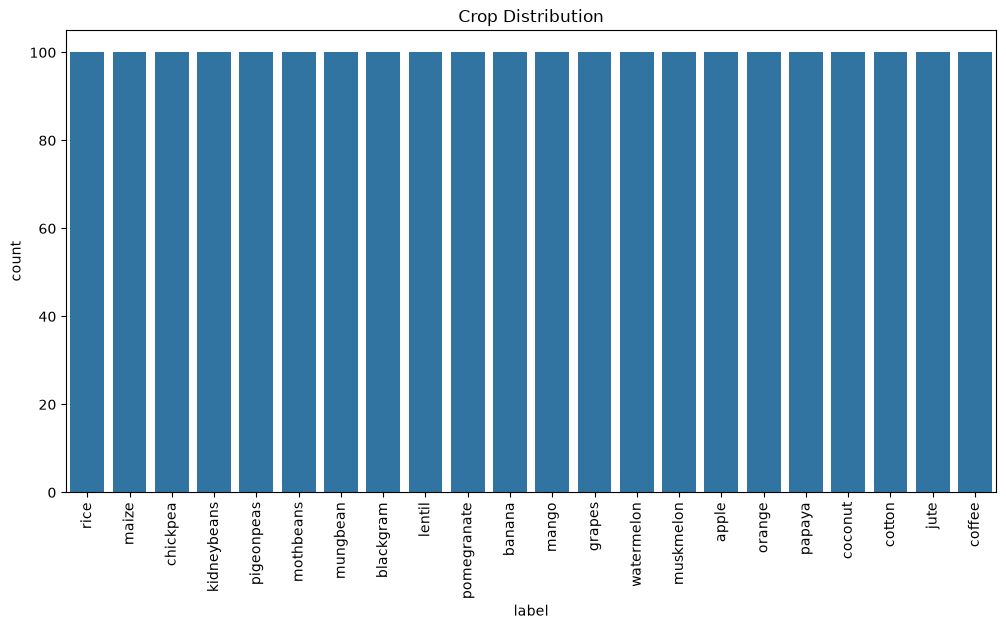

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


In [ ]:
#distribusi tanaman 
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="label",
    order=df["label"].value_counts().index
)

plt.xticks(rotation=90)
plt.title("Crop Distribution")
plt.show()

print(df["label"].value_counts())

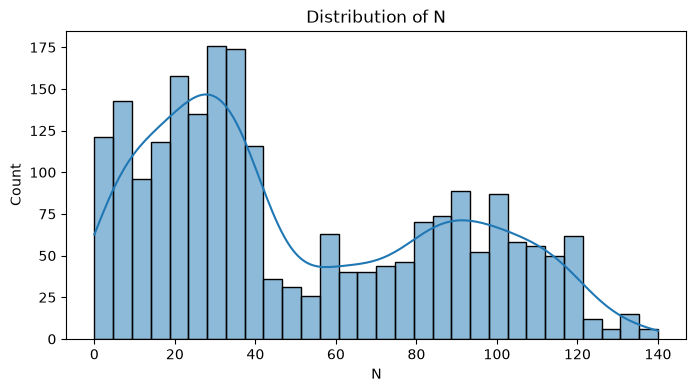

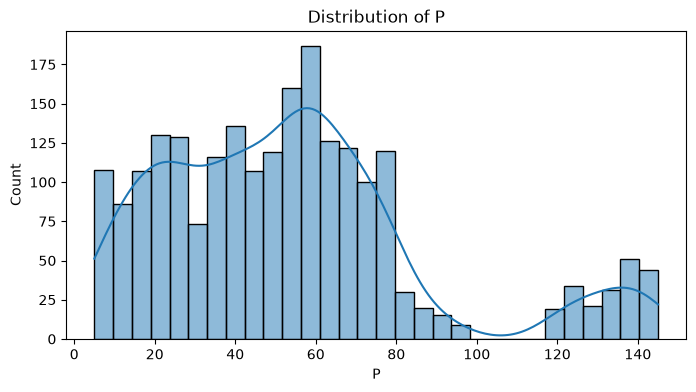

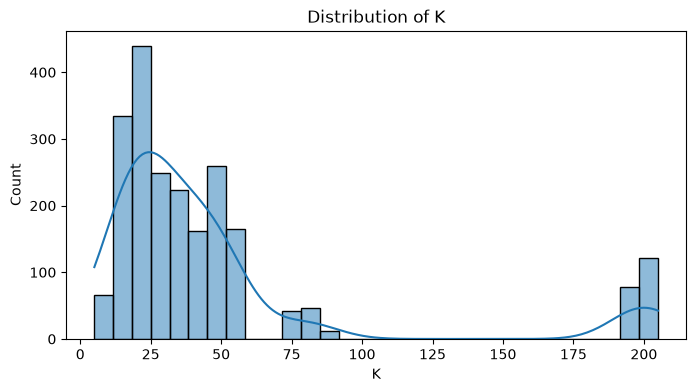

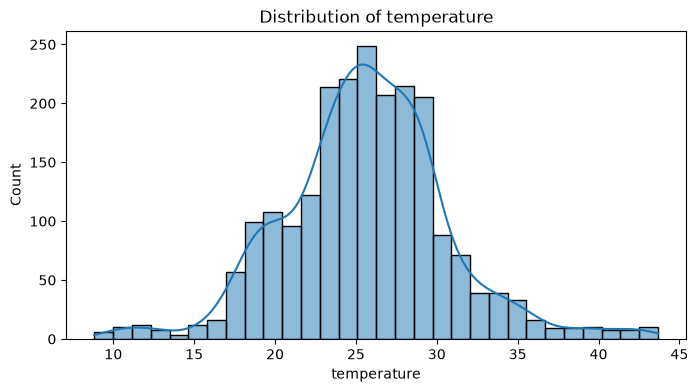

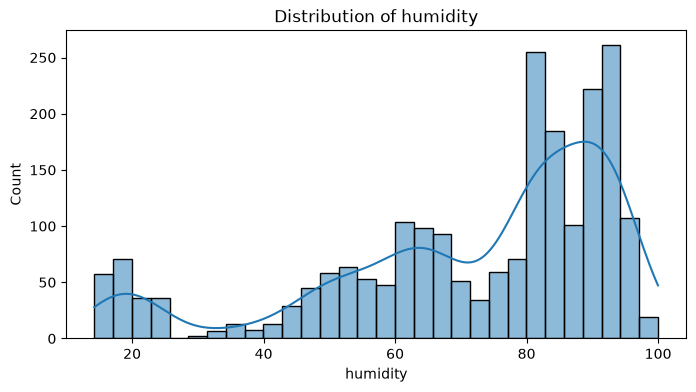

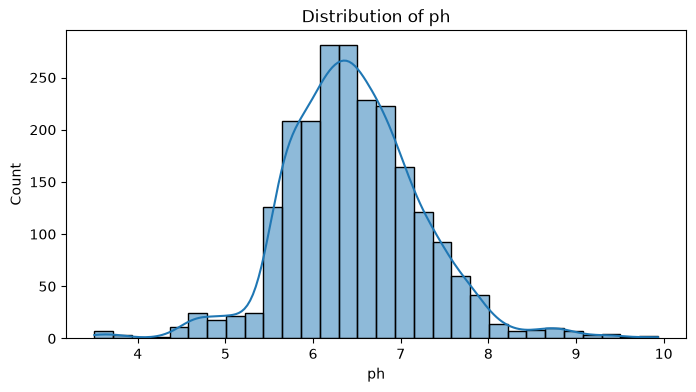

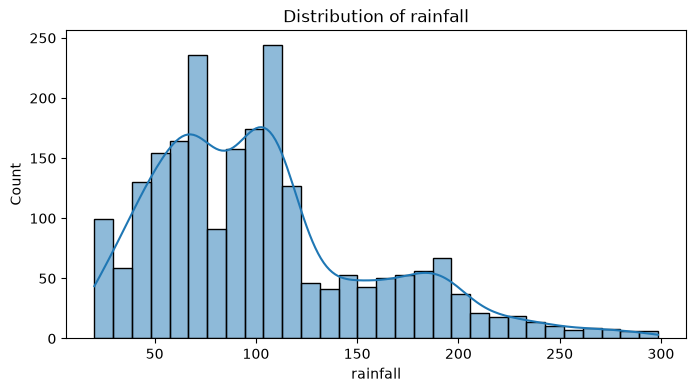

In [ ]:
#distribusi variabel numerik
numerical_cols = [
    "N",
    "P",
    "K",
    "temperature",
    "humidity",
    "ph",
    "rainfall"
]

for col in numerical_cols:

    plt.figure(figsize=(8,4))

    sns.histplot(
        df[col],
        kde=True,
        bins=30
    )

    plt.title(f"Distribution of {col}")
    plt.show()

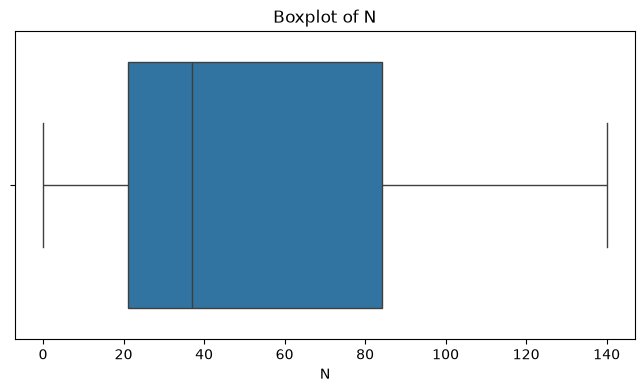

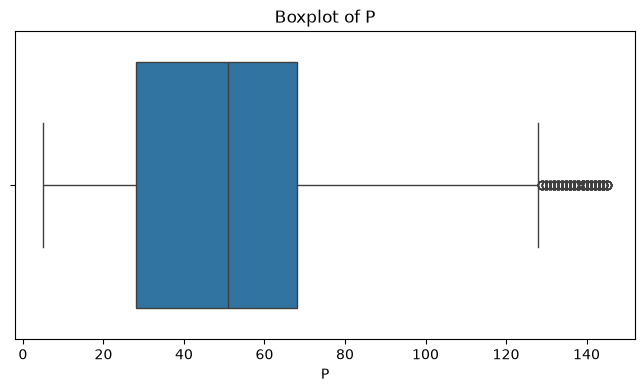

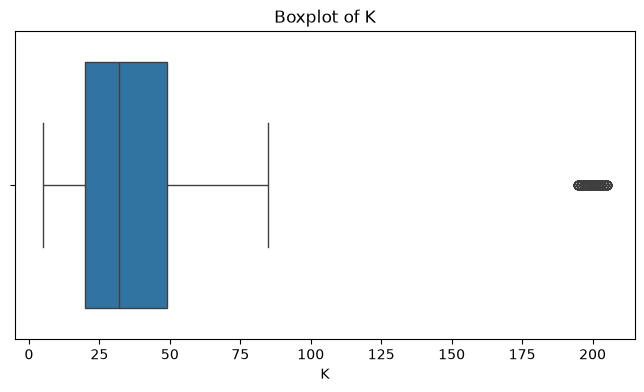

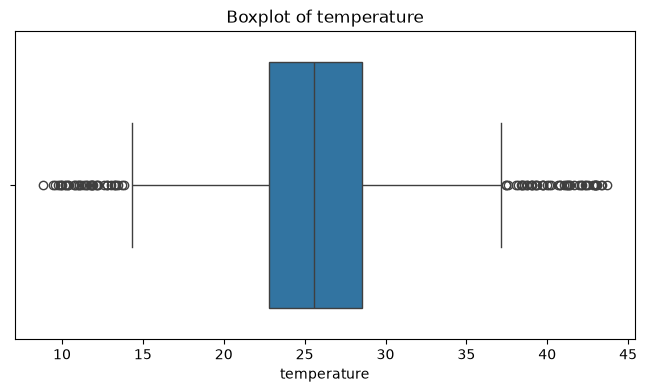

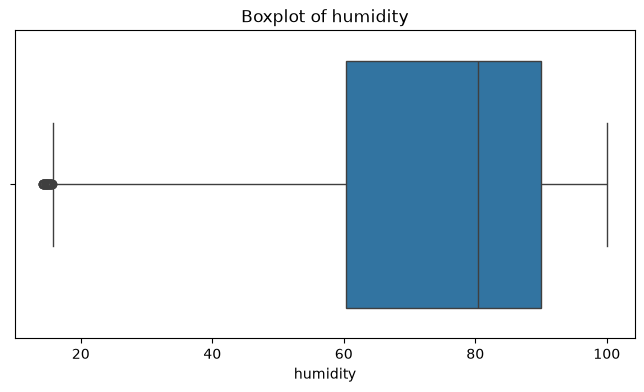

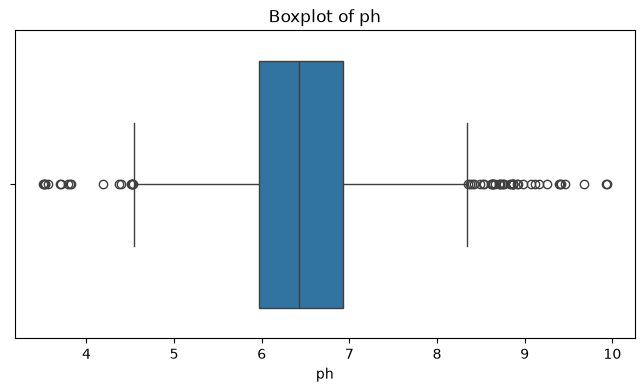

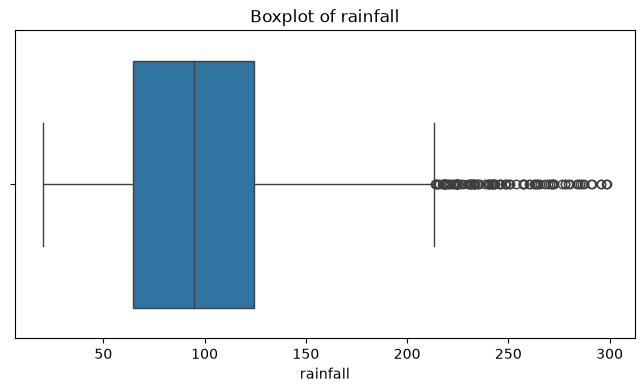

In [6]:
#boxplot outlier
for col in numerical_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Boxplot of {col}")

    plt.show()

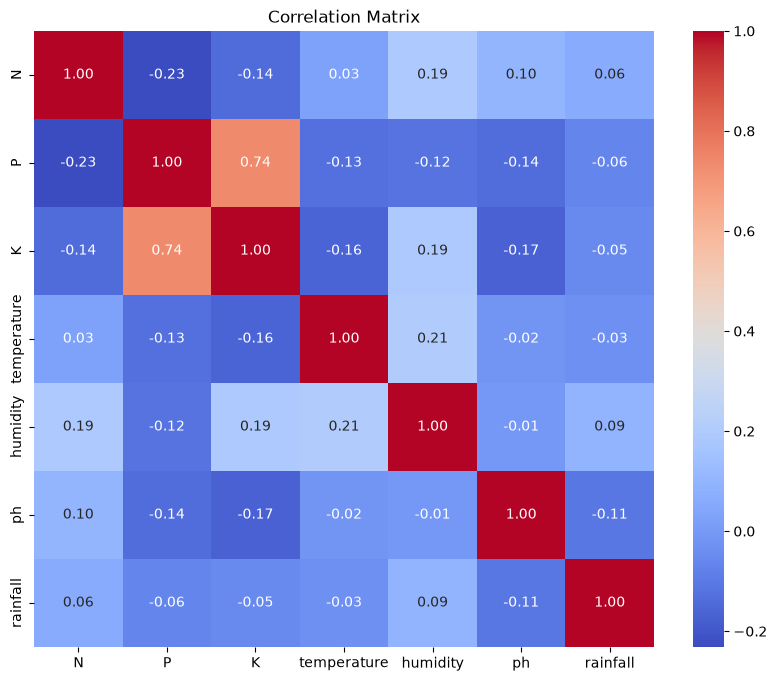

In [7]:
#correlation matrix 
plt.figure(figsize=(10,8))

corr = df[numerical_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [8]:
#rata-rata setiap tanaman 
crop_profile = (
    df.groupby("label")[numerical_cols]
      .mean()
      .round(2)
)

crop_profile

,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
apple,20.80,134.22,199.89,22.63,92.33,5.93,112.65
banana,100.23,82.01,50.05,27.38,80.36,5.98,104.63
blackgram,40.02,67.47,19.24,29.97,65.12,7.13,67.88
chickpea,40.09,67.79,79.92,18.87,16.86,7.34,80.06
coconut,21.98,16.93,30.59,27.41,94.84,5.98,175.69
coffee,101.20,28.74,29.94,25.54,58.87,6.79,158.07
cotton,117.77,46.24,19.56,23.99,79.84,6.91,80.40
grapes,23.18,132.53,200.11,23.85,81.88,6.03,69.61
jute,78.40,46.86,39.99,24.96,79.64,6.73,174.79


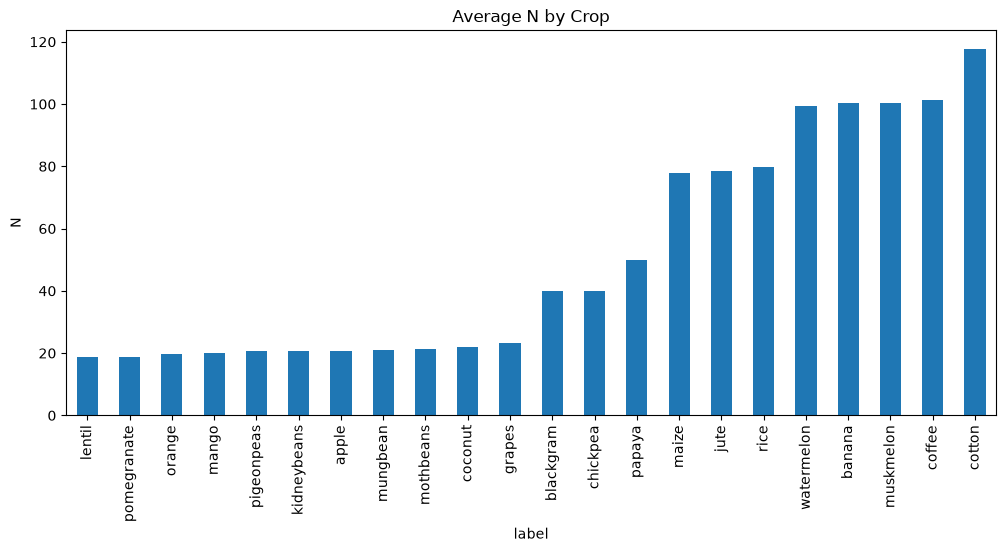

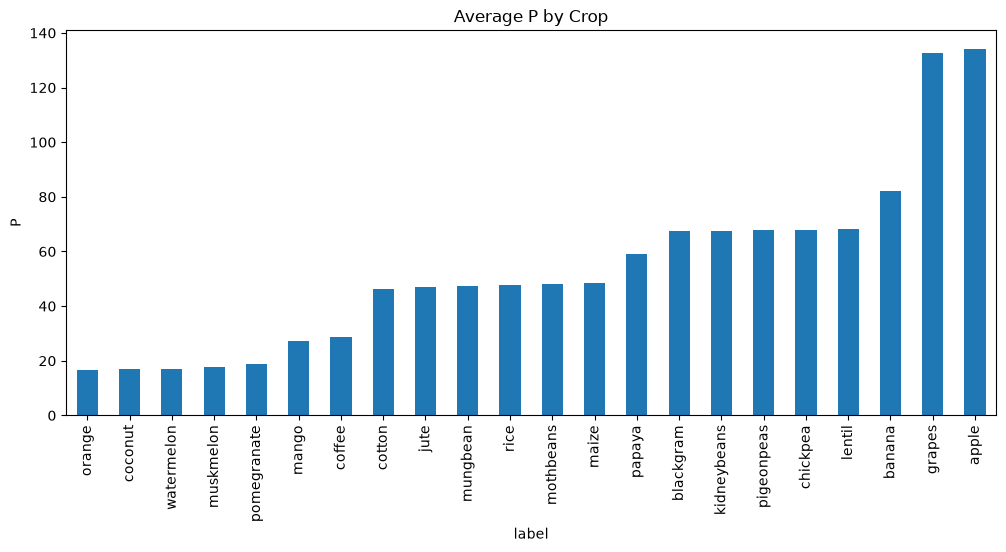

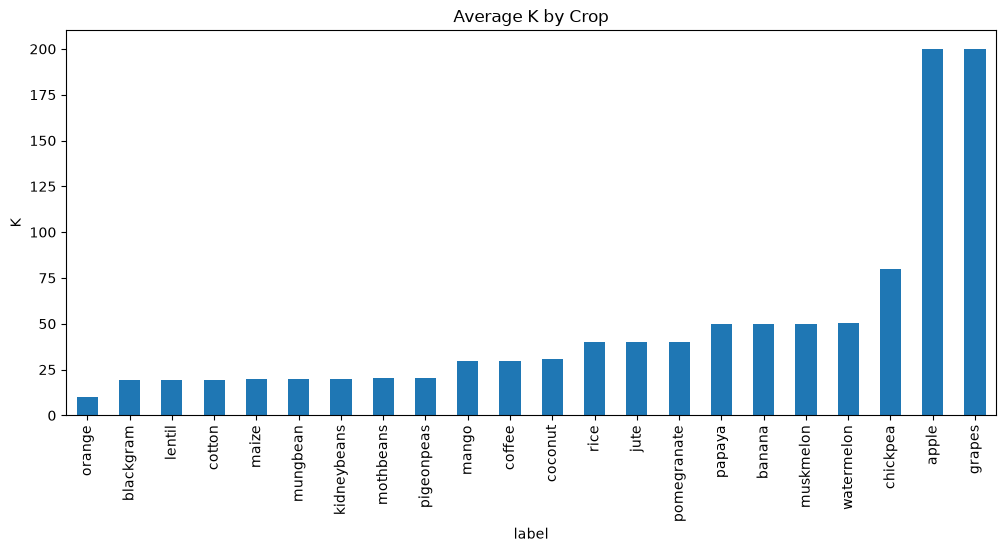

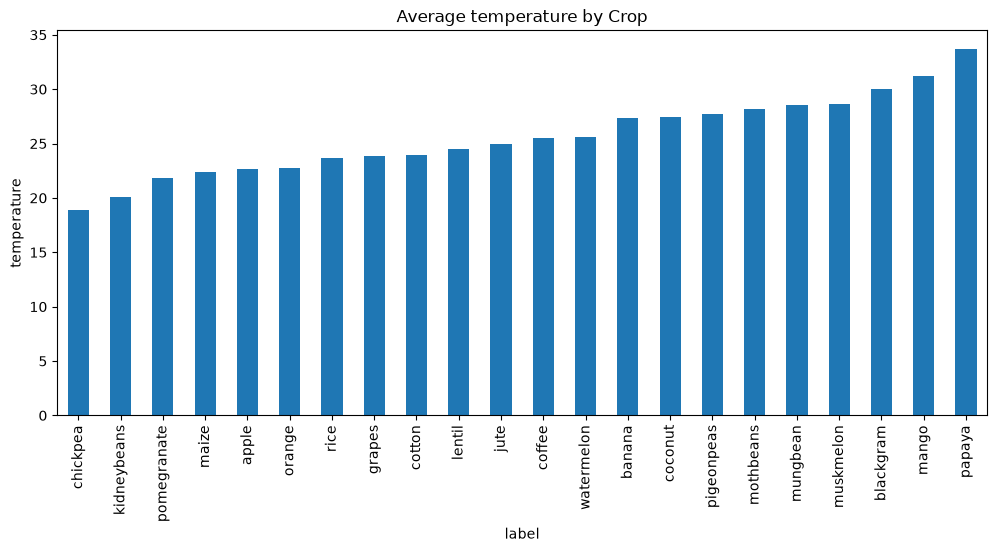

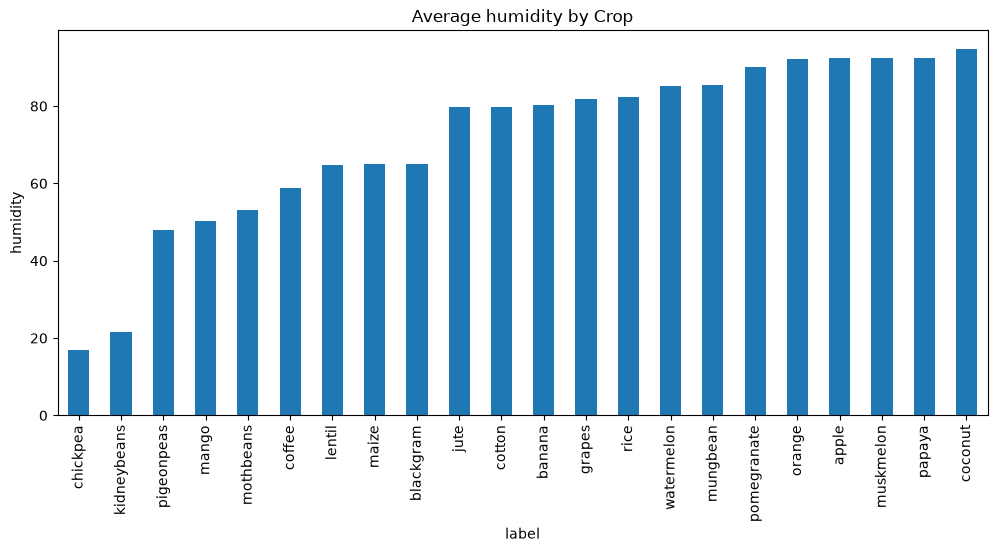

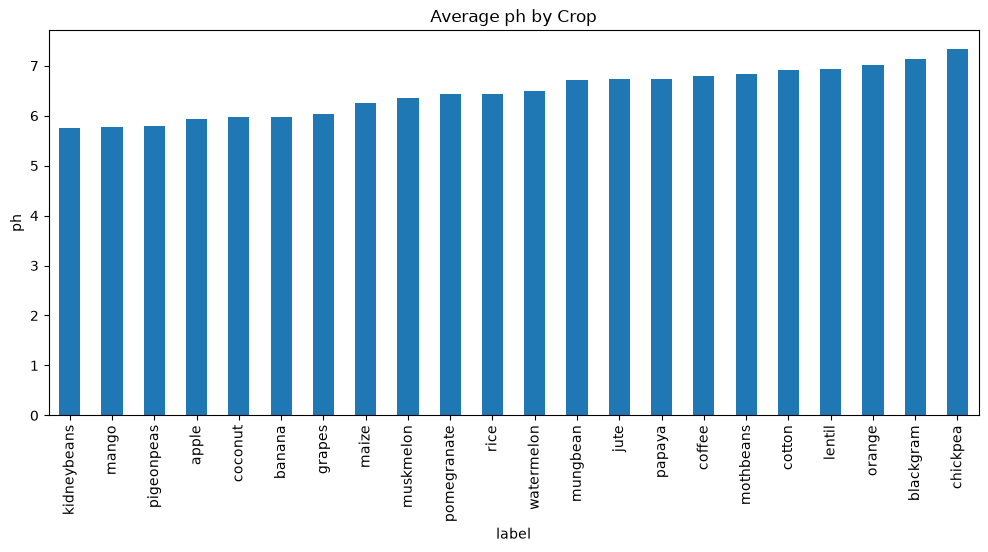

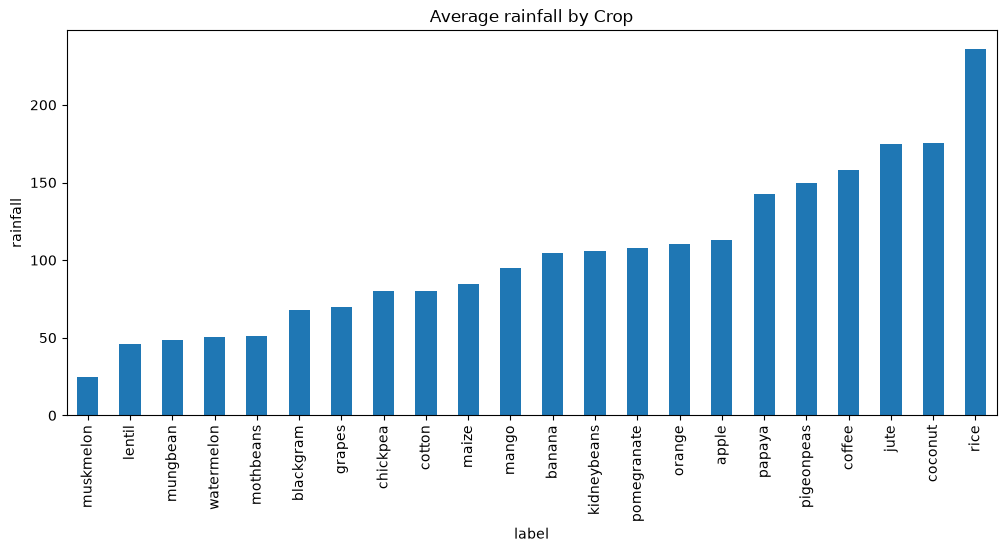

In [9]:
#visualisasi profil tanaman 
for col in numerical_cols:

    plt.figure(figsize=(12,5))

    crop_profile[col].sort_values().plot(
        kind="bar"
    )

    plt.title(f"Average {col} by Crop")

    plt.ylabel(col)

    plt.show()

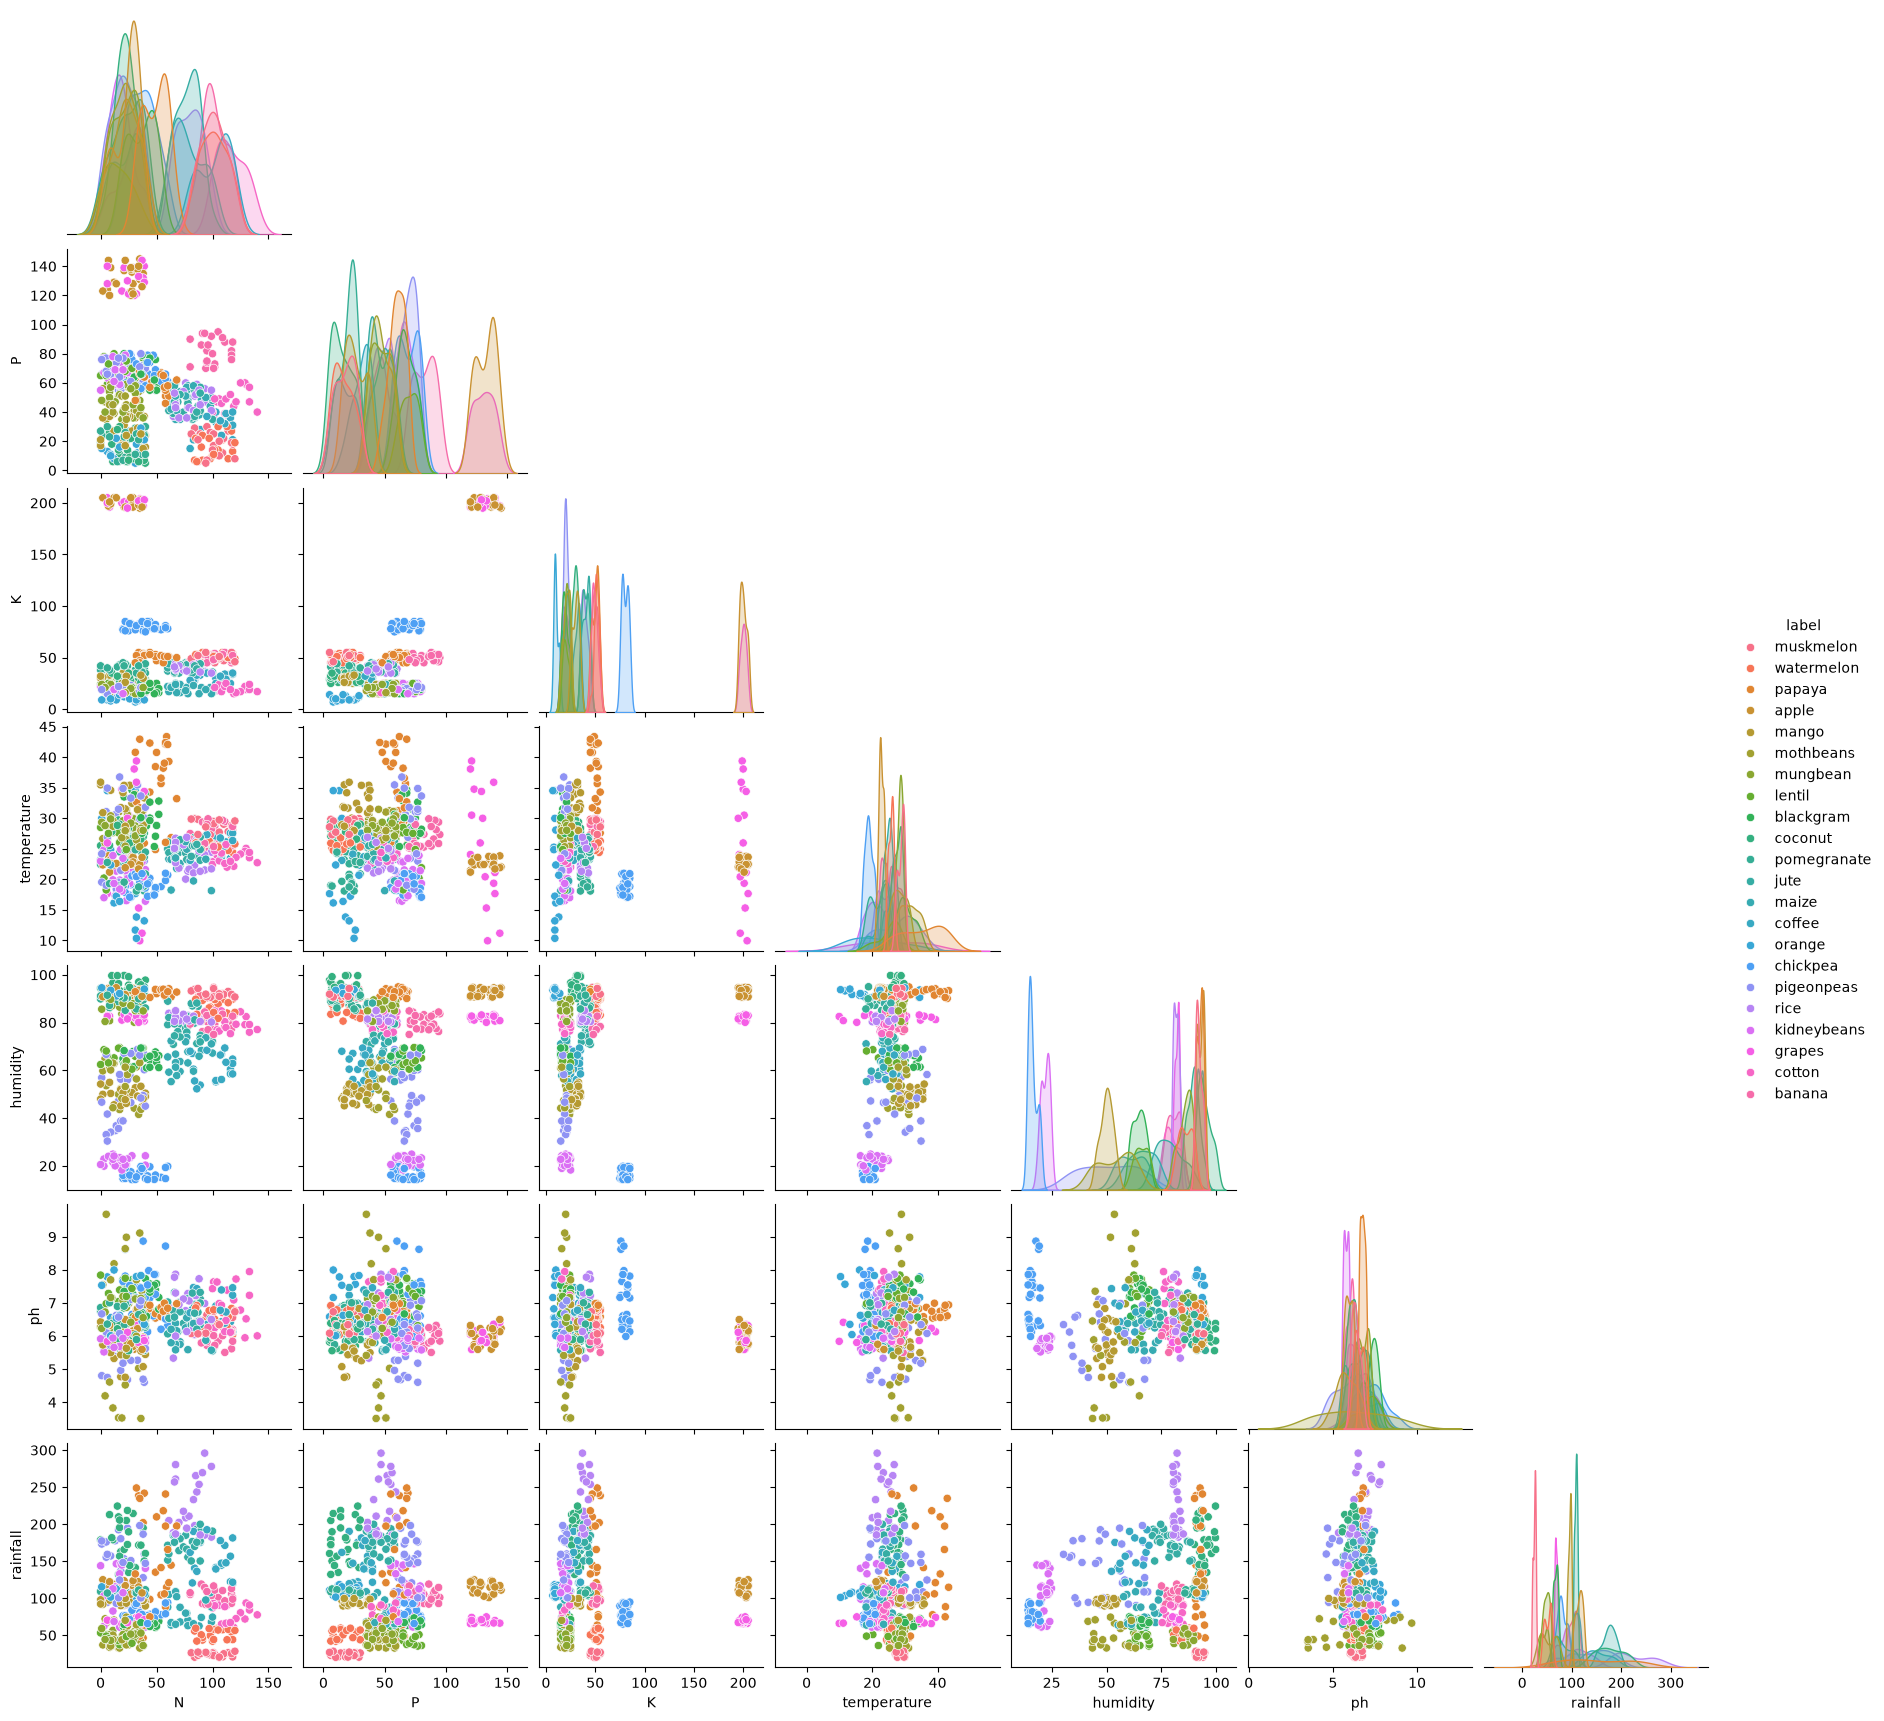

In [10]:
#pairplot 
sample_df = df.sample(
    min(500, len(df)),
    random_state=42
)

sns.pairplot(
    sample_df,
    hue="label",
    corner=True
)

plt.show()

In [ ]:
#membutuhkan nitrogen paling banyak untuk tanaman cotton (kapas)
crop_profile["N"].sort_values(ascending=False)

label
cotton         117.77
coffee         101.20
muskmelon      100.32
banana         100.23
watermelon      99.42
rice            79.89
jute            78.40
maize           77.76
papaya          49.88
chickpea        40.09
blackgram       40.02
grapes          23.18
coconut         21.98
mothbeans       21.44
mungbean        20.99
apple           20.80
kidneybeans     20.75
pigeonpeas      20.73
mango           20.07
orange          19.58
pomegranate     18.87
lentil          18.77
Name: N, dtype: float64

In [ ]:
#membutuhkan fosfor paling banyak untuk tanaman apple(apel)
crop_profile["P"].sort_values(ascending=False)

label
apple          134.22
grapes         132.53
banana          82.01
lentil          68.36
chickpea        67.79
pigeonpeas      67.73
kidneybeans     67.54
blackgram       67.47
papaya          59.05
maize           48.44
mothbeans       48.01
rice            47.58
mungbean        47.28
jute            46.86
cotton          46.24
coffee          28.74
mango           27.18
pomegranate     18.75
muskmelon       17.72
watermelon      17.00
coconut         16.93
orange          16.55
Name: P, dtype: float64

In [ ]:
#membutuhkan nitrogen tertinggi untuk tanaman grapes (anggur)
crop_profile["K"].sort_values(ascending=False)

label
grapes         200.11
apple          199.89
chickpea        79.92
watermelon      50.22
muskmelon       50.08
banana          50.05
papaya          50.04
pomegranate     40.21
jute            39.99
rice            39.87
coconut         30.59
coffee          29.94
mango           29.92
pigeonpeas      20.29
mothbeans       20.23
kidneybeans     20.05
mungbean        19.87
maize           19.79
cotton          19.56
lentil          19.41
blackgram       19.24
orange          10.01
Name: K, dtype: float64

In [ ]:
#pH ideal masing-masing tanaman 
crop_profile["ph"].sort_values()

label
kidneybeans    5.75
mango          5.77
pigeonpeas     5.79
apple          5.93
coconut        5.98
banana         5.98
grapes         6.03
maize          6.25
muskmelon      6.36
pomegranate    6.43
rice           6.43
watermelon     6.50
mungbean       6.72
jute           6.73
papaya         6.74
coffee         6.79
mothbeans      6.83
cotton         6.91
lentil         6.93
orange         7.02
blackgram      7.13
chickpea       7.34
Name: ph, dtype: float64

In [ ]:
#tanaman padi (rice) membutuhkan curah hujan paling banyak 
crop_profile["rainfall"].sort_values(ascending=False)

label
rice           236.18
coconut        175.69
jute           174.79
coffee         158.07
pigeonpeas     149.46
papaya         142.63
apple          112.65
orange         110.47
pomegranate    107.53
kidneybeans    105.92
banana         104.63
mango           94.70
maize           84.77
cotton          80.40
chickpea        80.06
grapes          69.61
blackgram       67.88
mothbeans       51.20
watermelon      50.79
mungbean        48.40
lentil          45.68
muskmelon       24.69
Name: rainfall, dtype: float64